# Baseline-модели для детекции AI-текстов

Два baseline: A (TF-IDF + LogReg) и B (стилистические признаки + LogReg). Разница между ними показывает, какая доля сигнала приходится на тему, а какая на стиль.

## Окружение

In [ ]:
import re
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.sparse import hstack
from scipy.stats import chi2 as chi2_dist
from sklearn.calibration import calibration_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

In [ ]:
sns.set_theme(style="whitegrid", font_scale=1.1)
C_HUMAN = "#4C72B0"
C_AI    = "#DD8452"

plt.rcParams.update({
    "figure.dpi": 130, "figure.facecolor": "white",
    "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.labelsize": 11, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
})

DATA_DIR = Path("..") / "data" / "splits"
ARTIFACTS_DIR = Path("..") / "artifacts"
ARTIFACTS_DIR.mkdir(exist_ok=True)
print(f"Splits: {DATA_DIR.resolve()}")
print(f"Artifacts: {ARTIFACTS_DIR.resolve()}")

## Загрузка данных

In [32]:
train = pd.read_json(DATA_DIR / "train.jsonl", lines=True)
val   = pd.read_json(DATA_DIR / "val.jsonl", lines=True)
test  = pd.read_json(DATA_DIR / "test.jsonl", lines=True)
holdout = pd.read_json(DATA_DIR / "holdout_unseen.jsonl", lines=True)

test_clean = test[test["source_model"] != "adversarial"].copy()
test_adv   = test[test["source_model"] == "adversarial"].copy()

for name, df in [("train", train), ("val", val), ("test_clean", test_clean),
                 ("test_adv", test_adv), ("holdout", holdout)]:
    vc = df["label"].value_counts()
    print(f"{name:12s}: {len(df):>6,}  (human={vc.get(0,0):,}, AI={vc.get(1,0):,})")

train       : 19,026  (human=9,440, AI=9,586)
val         :  2,465  (human=1,257, AI=1,208)
test_clean  :  3,673  (human=1,885, AI=1,788)
test_adv    :    511  (human=0, AI=511)
holdout     :  5,896  (human=2,948, AI=2,948)


## Feature engineering

### Стилистические признаки (Baseline B)

Признаки не зависят от темы. `avg_word_len` - средняя длина слов.

note: `text_len` и `word_count` зависят от формата сбора, это не чисто стилистические признаки. `ends_formulaic` скорее лексический детектор LLM-артефактов.

In [ ]:
FORMULAIC_RE = re.compile(
    r"в заключение|таким образом|подводя итог|в целом,?\s|резюмируя|итак,",
    re.IGNORECASE,
)


def extract_style_features(df: pd.DataFrame) -> pd.DataFrame:
    """Стилистические фичи, инвариантные к теме."""
    t = df["text"]
    f = pd.DataFrame(index=df.index)

    f["text_len"] = t.str.len()
    words = t.str.split()
    f["word_count"] = words.str.len()
    f["sentence_count"] = t.apply(
        lambda x: max(len(re.split(r"[.!?]+", x.strip())) - 1, 1)
    )
    # avg_word_len без пробелов и пунктуации
    f["avg_word_len"] = words.apply(
        lambda ws: np.mean([len(w) for w in ws]) if ws else 0
    )
    f["avg_sent_len"] = f["word_count"] / f["sentence_count"]
    f["comma_density"] = t.apply(
        lambda x: x.count(",") / max(len(re.split(r"[.!?]+", x.strip())) - 1, 1)
    )
    f["question_marks"] = t.str.count(r"\?")
    f["exclamation_marks"] = t.str.count("!")

    word_lists = t.apply(lambda x: re.findall(r"[а-яёa-z]+", x.lower()))
    f["ttr"] = word_lists.apply(lambda ws: len(set(ws)) / max(len(ws), 1))

    f["ends_formulaic"] = t.apply(
        lambda x: int(bool(FORMULAIC_RE.search(x[-300:]))) if len(x) > 100 else 0
    )
    return f


STYLE_COLS = [
    "text_len", "word_count", "sentence_count", "avg_word_len", "avg_sent_len",
    "comma_density", "question_marks", "exclamation_marks", "ttr", "ends_formulaic",
]

In [ ]:
style_train   = extract_style_features(train)
style_val     = extract_style_features(val)
style_test    = extract_style_features(test)
style_holdout = extract_style_features(holdout)

print(f"Фичей: {len(STYLE_COLS)}")
print(f"avg_word_len (train): human={style_train.loc[train['label']==0, 'avg_word_len'].mean():.2f}, "
      f"AI={style_train.loc[train['label']==1, 'avg_word_len'].mean():.2f}")
style_train.describe().round(2)

Средняя длина слова различается: human ~7.5 vs AI ~7.9. `ends_formulaic` у людей 1.5%, у AI - 17%. Остальные признаки зашумлены, но 10 в совокупности могут дать разделение.

## Baseline A: TF-IDF + LogReg

In [34]:
# char + word TF-IDF
tfidf_char = TfidfVectorizer(
    analyzer="char_wb", ngram_range=(3, 5),
    max_features=30_000, sublinear_tf=True,
)
tfidf_word = TfidfVectorizer(
    analyzer="word", ngram_range=(1, 2),
    max_features=20_000, sublinear_tf=True,
    token_pattern=r"(?i)[а-яёa-z]{2,}",
)

X_train_char = tfidf_char.fit_transform(train["text"])
X_train_word = tfidf_word.fit_transform(train["text"])
X_train_A = hstack([X_train_char, X_train_word])

X_val_char = tfidf_char.transform(val["text"])
X_val_word = tfidf_word.transform(val["text"])
X_val_A = hstack([X_val_char, X_val_word])

y_train = train["label"].values
y_val   = val["label"].values

print(f"TF-IDF: char={X_train_char.shape[1]:,} + word={X_train_word.shape[1]:,} = {X_train_A.shape[1]:,}")

TF-IDF: char=30,000 + word=20,000 = 50,000


In [35]:
# подбор C на val
best_c, best_f1 = 1.0, 0.0
for c in [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 20.0, 50.0]:
    lr = LogisticRegression(C=c, solver="saga", max_iter=1000, random_state=42, n_jobs=-1)
    lr.fit(X_train_A, y_train)
    pred = lr.predict(X_val_A)
    f1 = f1_score(y_val, pred, average="macro")
    auc = roc_auc_score(y_val, lr.predict_proba(X_val_A)[:, 1])
    print(f"  C={c:<5}  F1={f1:.4f}  AUC={auc:.4f}")
    if f1 > best_f1:
        best_f1, best_c = f1, c

print(f"\nЛучший C={best_c} (val F1={best_f1:.4f})")

  C=0.01   F1=0.9700  AUC=0.9969
  C=0.1    F1=0.9854  AUC=0.9993
  C=0.5    F1=0.9931  AUC=0.9998
  C=1.0    F1=0.9947  AUC=0.9999
  C=5.0    F1=0.9976  AUC=1.0000
  C=10.0   F1=0.9984  AUC=1.0000
  C=20.0   F1=0.9988  AUC=1.0000
  C=50.0   F1=0.9988  AUC=1.0000

Лучший C=20.0 (val F1=0.9988)


In [36]:
# модель A на на train+val
X_trainval_A = hstack([
    tfidf_char.transform(pd.concat([train, val])["text"]),
    tfidf_word.transform(pd.concat([train, val])["text"]),
])
y_trainval = pd.concat([train, val])["label"].values

model_A = LogisticRegression(C=best_c, solver="saga", max_iter=1000, random_state=42, n_jobs=-1)
model_A.fit(X_trainval_A, y_trainval)
print(f"Baseline A: C={best_c}, обучен на train+val ({len(y_trainval):,})")

Baseline A: C=20.0, обучен на train+val (21,491)


## Baseline B: Style Features + LogReg

In [37]:
X_train_B = style_train[STYLE_COLS].values
X_val_B   = style_val[STYLE_COLS].values

scaler = StandardScaler()
X_train_B_s = scaler.fit_transform(X_train_B)
X_val_B_s   = scaler.transform(X_val_B)

best_c_b, best_f1_b = 1.0, 0.0
for c in [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0]:
    lr = LogisticRegression(C=c, solver="lbfgs", max_iter=5000, random_state=42)
    lr.fit(X_train_B_s, y_train)
    pred = lr.predict(X_val_B_s)
    f1 = f1_score(y_val, pred, average="macro")
    auc = roc_auc_score(y_val, lr.predict_proba(X_val_B_s)[:, 1])
    print(f"  C={c:<5}  F1={f1:.4f}  AUC={auc:.4f}")
    if f1 > best_f1_b:
        best_f1_b, best_c_b = f1, c

print(f"\nЛучший C={best_c_b} (val F1={best_f1_b:.4f})")

  C=0.01   F1=0.7265  AUC=0.8156
  C=0.1    F1=0.7332  AUC=0.8216
  C=0.5    F1=0.7339  AUC=0.8251
  C=1.0    F1=0.7374  AUC=0.8257
  C=5.0    F1=0.7389  AUC=0.8253
  C=10.0   F1=0.7401  AUC=0.8252
  C=50.0   F1=0.7404  AUC=0.8251

Лучший C=50.0 (val F1=0.7404)


In [38]:
# модель B на на train+val
X_trainval_B = scaler.fit_transform(
    pd.concat([style_train, style_val])[STYLE_COLS].values
)
y_trainval_b = pd.concat([train, val])["label"].values

model_B = LogisticRegression(C=best_c_b, solver="lbfgs", max_iter=5000, random_state=42)
model_B.fit(X_trainval_B, y_trainval_b)
print(f"Baseline B: C={best_c_b}, обучен на train+val ({len(y_trainval_b):,})")

Baseline B: C=50.0, обучен на train+val (21,491)


## Вспомогательные функции

Тут bootstrap CI, McNemar и ECE. Возможно, стоило вынести в отдельный модуль, но пока пусть живёт здесь.

In [ ]:
def bootstrap_ci(y_true, y_pred, metric_fn, n_boot=1000, ci=95, seed=42):
    """Bootstrap CI для метрики."""
    rng = np.random.RandomState(seed)
    scores = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.randint(0, n, size=n)
        try:
            scores.append(metric_fn(y_true[idx], y_pred[idx]))
        except ValueError:
            continue
    lo = np.percentile(scores, (100 - ci) / 2)
    hi = np.percentile(scores, 100 - (100 - ci) / 2)
    return np.median(scores), lo, hi


def mcnemar_test(pred_a, pred_b, y_true):
    """Тест Макнемара: значимость разницы двух моделей."""
    correct_a = (pred_a == y_true)
    correct_b = (pred_b == y_true)
    # b - A правильно, B неправильно
    b = int((correct_a & ~correct_b).sum())
    c = int((~correct_a & correct_b).sum())
    if b + c == 0:
        return 1.0, b, c
    stat = (abs(b - c) - 1) ** 2 / (b + c)
    p = 1 - chi2_dist.cdf(stat, df=1)
    return p, b, c


def ece_score(y_true, y_prob, n_bins=10):
    """Ожидаемая ошибка калибровки (ECE)."""
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (y_prob >= lo) & (y_prob < hi)
        if mask.sum() == 0:
            continue
        avg_conf = y_prob[mask].mean()
        avg_acc = y_true[mask].mean()
        ece += mask.sum() / len(y_true) * abs(avg_conf - avg_acc)
    return ece

### evaluate()

In [ ]:
def evaluate(model, X, y, name="", domain=None, source_model=None):
    """Оценка модели с CI, по доменам и по моделям."""
    pred = model.predict(X)
    prob = model.predict_proba(X)[:, 1]

    print(f"=== {name} (n={len(y):,}) ===")
    print(classification_report(y, pred, target_names=["human", "AI"], digits=3))

    # метрики + CI
    for metric_name, fn in [("F1-macro", lambda yt, yp: f1_score(yt, yp, average="macro")),
                            ("Accuracy", accuracy_score)]:
        med, lo, hi = bootstrap_ci(y, pred, fn)
        print(f"{metric_name}: {med:.3f} [{lo:.3f}, {hi:.3f}] (95% CI)")

    auc = roc_auc_score(y, prob)
    auc_med, auc_lo, auc_hi = bootstrap_ci(
        y, prob, lambda yt, yp: roc_auc_score(yt, yp))
    print(f"AUC-ROC:  {auc_med:.3f} [{auc_lo:.3f}, {auc_hi:.3f}]")
    print(f"ECE:      {ece_score(y, prob):.4f}")
    print()

    # матрица ошибок
    cm = confusion_matrix(y, pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["human", "AI"], yticklabels=["human", "AI"])
    ax.set_xlabel("predicted")
    ax.set_ylabel("actual")
    ax.set_title(f"{name}")
    plt.tight_layout()
    plt.show()

    # по доменам
    if domain is not None:
        print("Per-domain:")
        for dom in sorted(np.unique(domain)):
            mask = domain == dom
            if mask.sum() < 2:
                continue
            dom_f1 = f1_score(y[mask], pred[mask], average="macro")
            dom_auc = roc_auc_score(y[mask], prob[mask]) if len(np.unique(y[mask])) > 1 else 0
            print(f"  {dom:8s}: F1={dom_f1:.3f}  AUC={dom_auc:.3f}  n={mask.sum()}")
        print()

    # по моделям
    if source_model is not None:
        print("Per-model (AI only, recall / precision / F1 / avg_prob):")
        ai_mask = y == 1
        for mdl in sorted(np.unique(source_model[ai_mask])):
            mask = (source_model == mdl) & ai_mask
            if mask.sum() == 0:
                continue
            tp = ((pred[mask] == 1)).sum()
            recall = tp / mask.sum()

            # note: добавить точный precision per model
            avg_p = prob[mask].mean()
            print(f"  {mdl:28s}: recall={recall:.3f}  avg_prob={avg_p:.3f}  n={mask.sum()}")
        print()

    return pred, prob

## Evaluation на test

Результаты обеих моделей на тестовой выборке.

### Baseline A

=== Baseline A (TF-IDF) - test (n=3,673) ===
              precision    recall  f1-score   support

       human      0.988     0.999     0.994      1885
          AI      0.999     0.988     0.994      1788

    accuracy                          0.994      3673
   macro avg      0.994     0.994     0.994      3673
weighted avg      0.994     0.994     0.994      3673

F1-macro: 0.994 [0.991, 0.996] (95% CI)
Accuracy: 0.994 [0.991, 0.996] (95% CI)
AUC-ROC:  1.000 [1.000, 1.000]
ECE:      0.0132



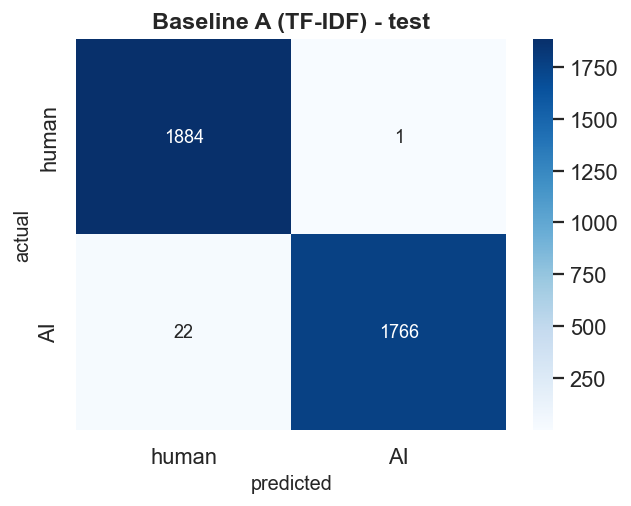

Per-domain:
  essay   : F1=1.000  AUC=1.000  n=933
  news    : F1=0.986  AUC=1.000  n=1576
  wiki    : F1=0.999  AUC=1.000  n=1164

Per-model (AI only, recall / precision / F1 / avg_prob):
  GigaChat                    : recall=0.989  avg_prob=0.961  n=547
  gemini-2.5-flash-lite       : recall=0.983  avg_prob=0.963  n=242
  llama-3.3-70b-versatile     : recall=0.985  avg_prob=0.964  n=268
  yandexgpt-lite              : recall=0.989  avg_prob=0.981  n=731



In [40]:
X_test_A = hstack([tfidf_char.transform(test_clean["text"]),
                   tfidf_word.transform(test_clean["text"])])
y_test = test_clean["label"].values

pred_A, prob_A = evaluate(
    model_A, X_test_A, y_test, "Baseline A (TF-IDF) - test",
    domain=test_clean["domain"].values,
    source_model=test_clean["source_model"].values,
)

### Baseline B

=== Baseline B (Style) - test (n=3,673) ===
              precision    recall  f1-score   support

       human      0.754     0.791     0.772      1885
          AI      0.768     0.728     0.747      1788

    accuracy                          0.760      3673
   macro avg      0.761     0.759     0.759      3673
weighted avg      0.760     0.760     0.760      3673

F1-macro: 0.760 [0.746, 0.772] (95% CI)
Accuracy: 0.760 [0.747, 0.773] (95% CI)
AUC-ROC:  0.852 [0.840, 0.864]
ECE:      0.0562



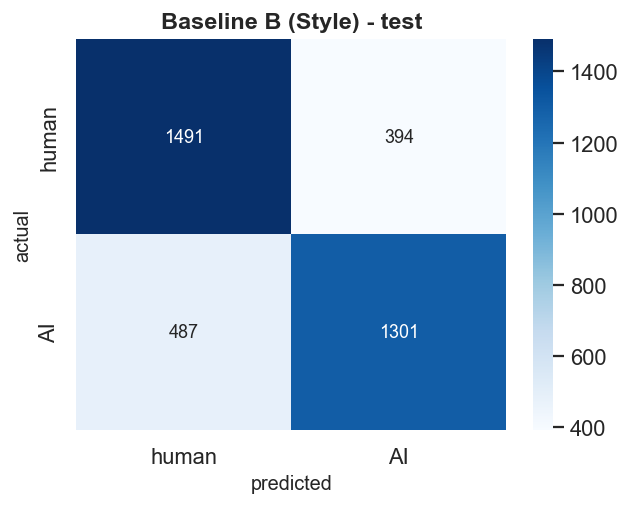

Per-domain:
  essay   : F1=0.834  AUC=0.908  n=933
  news    : F1=0.596  AUC=0.625  n=1576
  wiki    : F1=0.917  AUC=0.962  n=1164

Per-model (AI only, recall / precision / F1 / avg_prob):
  GigaChat                    : recall=0.686  avg_prob=0.691  n=547
  gemini-2.5-flash-lite       : recall=0.740  avg_prob=0.709  n=242
  llama-3.3-70b-versatile     : recall=0.705  avg_prob=0.655  n=268
  yandexgpt-lite              : recall=0.763  avg_prob=0.707  n=731



In [41]:
X_test_B = scaler.transform(style_test.loc[test_clean.index, STYLE_COLS].values)

pred_B, prob_B = evaluate(
    model_B, X_test_B, y_test, "Baseline B (Style) - test",
    domain=test_clean["domain"].values,
    source_model=test_clean["source_model"].values,
)

## Holdout - unseen generator (yandexgpt)

Самое интересное - видела ли модель yandexgpt при обучении? Нет. Проверим, как она с ним справится.

=== Baseline A ===
=== A - holdout (yandexgpt) (n=5,896) ===
              precision    recall  f1-score   support

       human      0.999     0.999     0.999      2948
          AI      0.999     0.999     0.999      2948

    accuracy                          0.999      5896
   macro avg      0.999     0.999     0.999      5896
weighted avg      0.999     0.999     0.999      5896

F1-macro: 0.999 [0.998, 1.000] (95% CI)
Accuracy: 0.999 [0.998, 1.000] (95% CI)
AUC-ROC:  1.000 [1.000, 1.000]
ECE:      0.0030



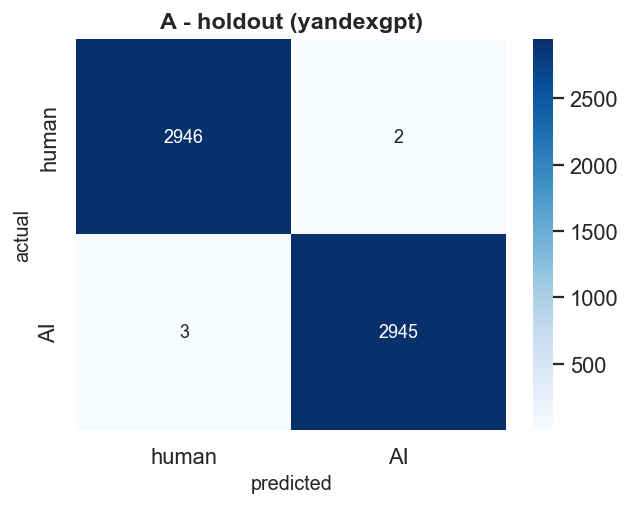

Per-domain:
  essay   : F1=0.999  AUC=1.000  n=1734
  news    : F1=0.999  AUC=1.000  n=2212
  wiki    : F1=0.999  AUC=1.000  n=1950

Per-model (AI only, recall / precision / F1 / avg_prob):
  yandexgpt                   : recall=0.999  avg_prob=0.997  n=2948


=== Baseline B ===
=== B - holdout (yandexgpt) (n=5,896) ===
              precision    recall  f1-score   support

       human      0.801     0.801     0.801      2948
          AI      0.801     0.802     0.801      2948

    accuracy                          0.801      5896
   macro avg      0.801     0.801     0.801      5896
weighted avg      0.801     0.801     0.801      5896

F1-macro: 0.802 [0.791, 0.811] (95% CI)
Accuracy: 0.802 [0.792, 0.811] (95% CI)
AUC-ROC:  0.883 [0.875, 0.891]
ECE:      0.0589



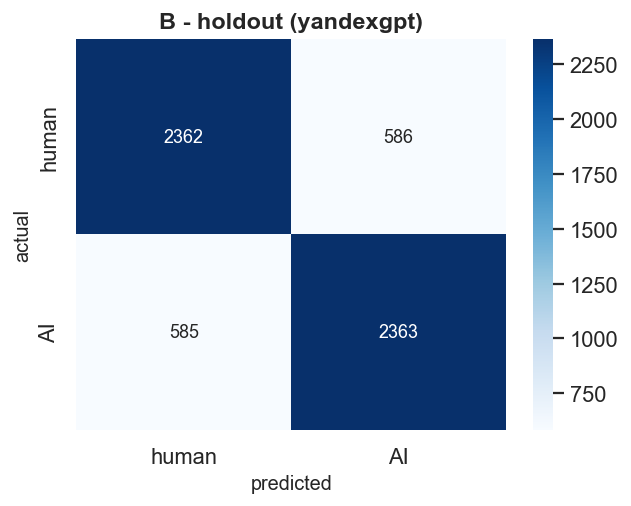

Per-domain:
  essay   : F1=0.829  AUC=0.890  n=1734
  news    : F1=0.671  AUC=0.741  n=2212
  wiki    : F1=0.917  AUC=0.957  n=1950

Per-model (AI only, recall / precision / F1 / avg_prob):
  yandexgpt                   : recall=0.802  avg_prob=0.703  n=2948



In [42]:
X_hold_A = hstack([tfidf_char.transform(holdout["text"]),
                   tfidf_word.transform(holdout["text"])])
X_hold_B = scaler.transform(style_holdout[STYLE_COLS].values)
y_hold = holdout["label"].values

print("=== Baseline A ===")
pred_hold_A, prob_hold_A = evaluate(
    model_A, X_hold_A, y_hold, "A - holdout (yandexgpt)",
    domain=holdout["domain"].values, source_model=holdout["source_model"].values)

print("\n=== Baseline B ===")
pred_hold_B, prob_hold_B = evaluate(
    model_B, X_hold_B, y_hold, "B - holdout (yandexgpt)",
    domain=holdout["domain"].values, source_model=holdout["source_model"].values)

## Adversarial evaluation

note: подумать, нужны ли более сложные adversarial-атаки (back-translation, переформулирование через другую LLM).

In [43]:
if len(test_adv) > 0:
    X_adv_A = hstack([tfidf_char.transform(test_adv["text"]),
                      tfidf_word.transform(test_adv["text"])])
    X_adv_B = scaler.transform(extract_style_features(test_adv)[STYLE_COLS].values)
    y_adv = test_adv["label"].values

    pred_adv_A = model_A.predict(X_adv_A)
    prob_adv_A = model_A.predict_proba(X_adv_A)[:, 1]
    pred_adv_B = model_B.predict(X_adv_B)
    prob_adv_B = model_B.predict_proba(X_adv_B)[:, 1]

    recall_A = (pred_adv_A == 1).mean()
    recall_B = (pred_adv_B == 1).mean()

    print(f"Adversarial (n={len(y_adv)}): парафразы AI -> label=1")
    print(f"  Baseline A: recall={recall_A:.3f}  avg_prob={prob_adv_A.mean():.3f}")
    print(f"  Baseline B: recall={recall_B:.3f}  avg_prob={prob_adv_B.mean():.3f}")
    print()
    print("Ожидаемо recall ниже, чем на обычных AI - парафраз маскирует стиль.")

Adversarial (n=511): парафразы AI -> label=1
  Baseline A: recall=0.908  avg_prob=0.890
  Baseline B: recall=0.546  avg_prob=0.576

Ожидаемо recall ниже, чем на обычных AI - парафраз маскирует стиль.


## Feature importance

### Baseline A: top TF-IDF n-grams

Если среди важных n-грамм преобладают тематические слова - модель опирается на тему, а не на стиль.

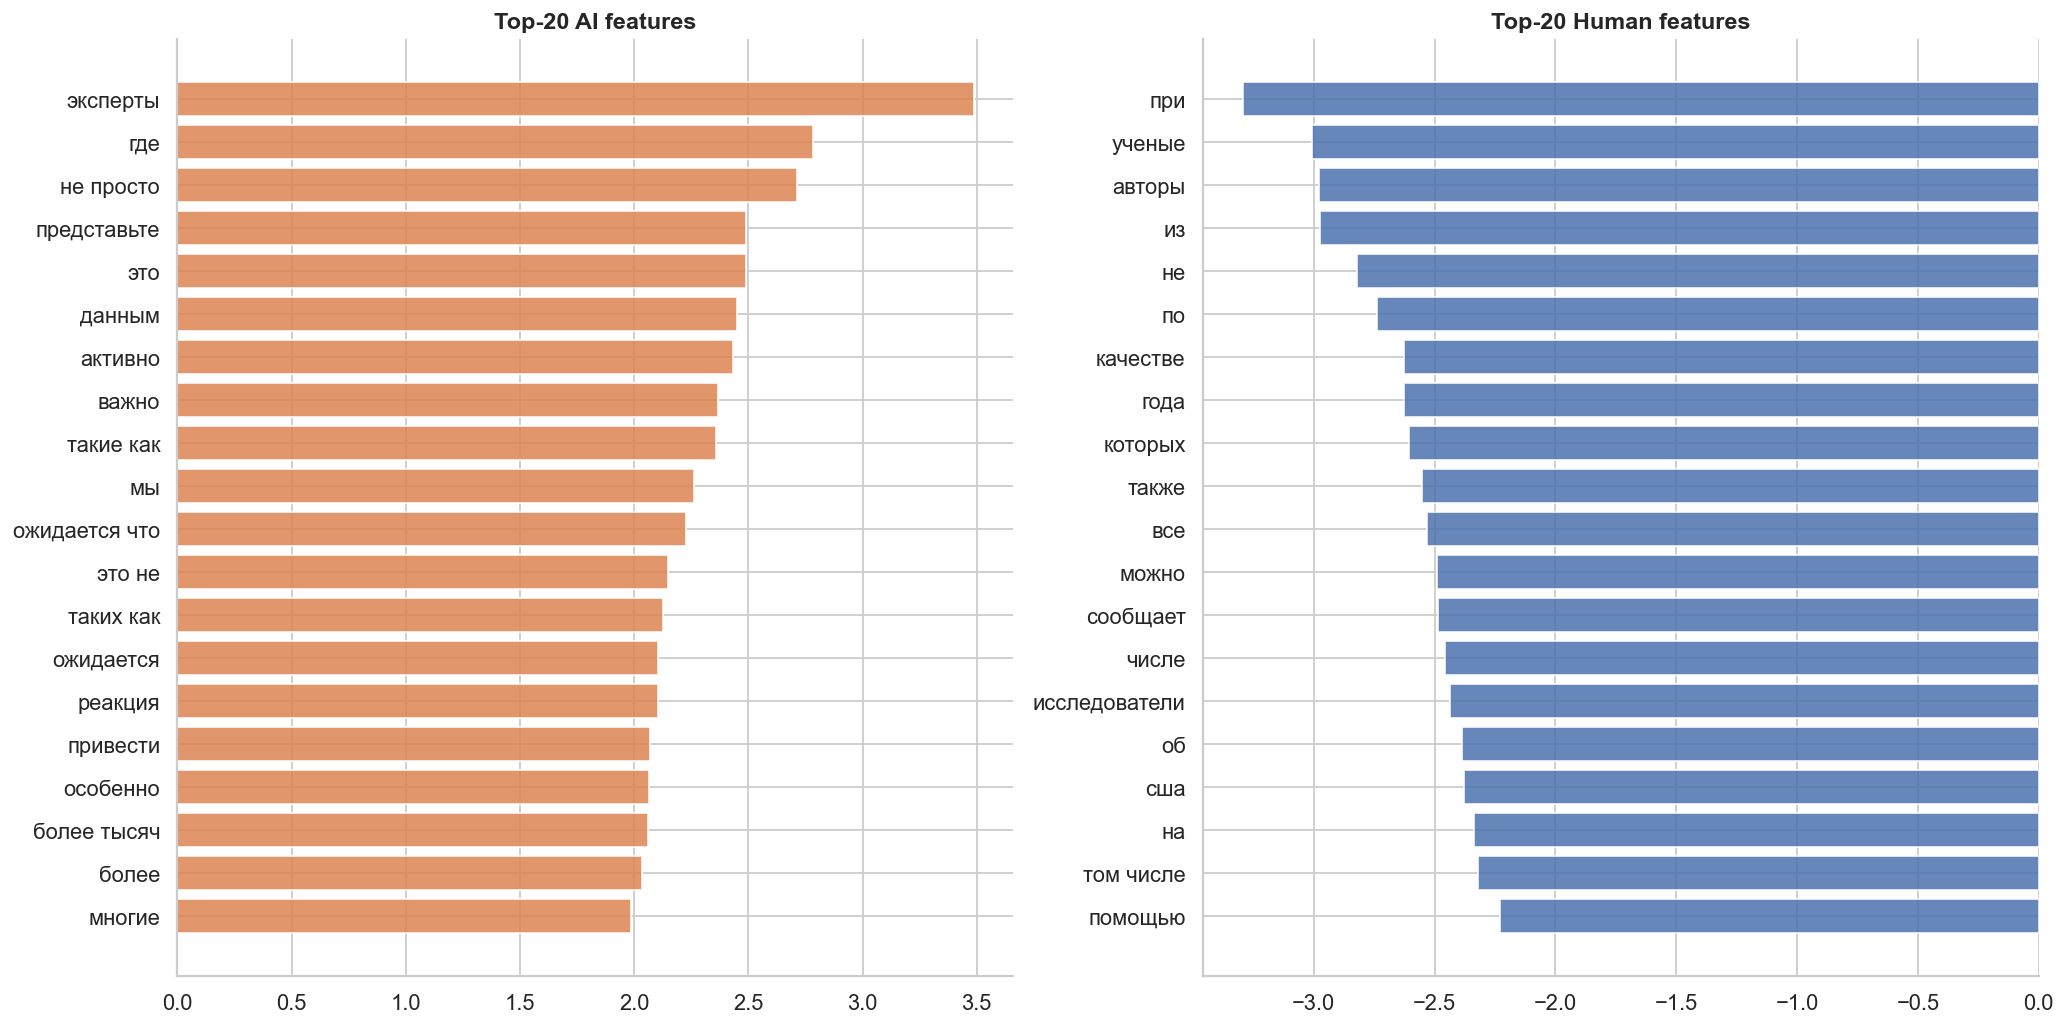

In [44]:
coef = model_A.coef_[0]
all_names = np.concatenate([tfidf_char.get_feature_names_out(),
                            tfidf_word.get_feature_names_out()])

n = 20
top_ai = coef.argsort()[-n:][::-1]
top_human = coef.argsort()[:n]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].barh(range(n), coef[top_ai], color=C_AI, alpha=0.85)
axes[0].set_yticks(range(n))
axes[0].set_yticklabels([all_names[i] for i in top_ai])
axes[0].set_title("Top-20 AI features")
axes[0].invert_yaxis()

axes[1].barh(range(n), coef[top_human], color=C_HUMAN, alpha=0.85)
axes[1].set_yticks(range(n))
axes[1].set_yticklabels([all_names[i] for i in top_human])
axes[1].set_title("Top-20 Human features")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### Baseline B: коэффициенты

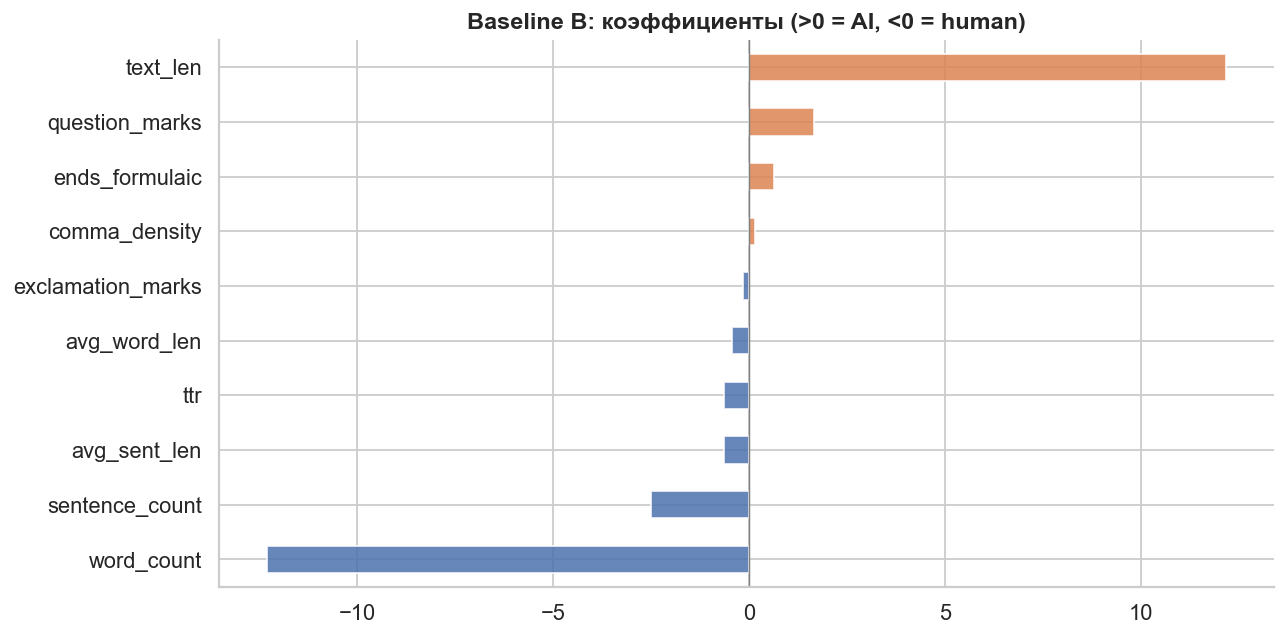

In [45]:
coef_B = model_B.coef_[0]
fi = pd.Series(coef_B, index=STYLE_COLS).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
colors = [C_HUMAN if v < 0 else C_AI for v in fi]
fi.plot.barh(ax=ax, color=colors, alpha=0.85)
ax.set_title("Baseline B: коэффициенты (>0 = AI, <0 = human)")
ax.axvline(0, color="grey", lw=0.8)
plt.tight_layout()
plt.show()

## Декомпозиция: topic vs style

note: это ключевой эксперимент. Если разница A-B большая, значит TF-IDF модель сильно опирается на тему, а не на стиль написания.

In [ ]:
acc_A = accuracy_score(y_test, pred_A)
acc_B = accuracy_score(y_test, pred_B)
f1_A = f1_score(y_test, pred_A, average="macro")
f1_B = f1_score(y_test, pred_B, average="macro")

print("ДЕКОМПОЗИЦИЯ СИГНАЛА")
print("=" * 50)
print(f"Baseline A (TF-IDF):     Acc={acc_A:.3f}  F1={f1_A:.3f}")
print(f"Baseline B (Style-only): Acc={acc_B:.3f}  F1={f1_B:.3f}")
print(f"Разница (A − B):         Acc={acc_A - acc_B:+.3f}  F1={f1_A - f1_B:+.3f}")
print()

# таблица согласованности
correct_A = (pred_A == y_test)
correct_B = (pred_B == y_test)
print("Agreement table:")
print(f"  A correct & B correct:   {(correct_A & correct_B).sum():>5}")
print(f"  A correct & B wrong:     {(correct_A & ~correct_B).sum():>5}")
print(f"  A wrong   & B correct:   {(~correct_A & correct_B).sum():>5}")
print(f"  A wrong   & B wrong:     {(~correct_A & ~correct_B).sum():>5}")
print()

# тест Макнемара
p_val, b, c = mcnemar_test(pred_A, pred_B, y_test)
print(f"McNemar's test: p={p_val:.4e} (b={b}, c={c})")
if p_val < 0.001:
    print("  -> Разница между A и B статистически значима.")
else:
    print("  -> Разница не значима.")
print()

# по доменам

In [ ]:
print("Per-domain декомпозиция (F1-macro):")
for dom in sorted(test_clean["domain"].unique()):
    mask = test_clean["domain"].values == dom
    f1a = f1_score(y_test[mask], pred_A[mask], average="macro")
    f1b = f1_score(y_test[mask], pred_B[mask], average="macro")
    print(f"  {dom:8s}: A={f1a:.3f}  B={f1b:.3f}  delta={f1a-f1b:+.3f}")
print()

delta = acc_A - acc_B
if delta > 0.15:
    print(f"⚠ Topic confound значителен ({delta:.1%}).")
    print("  -> DEC-008: topic-matched генерация рекомендуется.")
elif delta > 0.05:
    print(f"Topic confound умеренный ({delta:.1%}).")
else:
    print(f"Topic confound минимален ({delta:.1%}). Стилистический сигнал достаточен.")

Конфаунд сильнее всего в news (+39.0 п.п.): AI-промпты задают темы, которых нет в Taiga. Wiki минимален (+8.2 п.п.) - энциклопедический стиль сам по себе характерен. Essay посередине (+16.6 п.п.).

McNemar test: p < 0.001, разница A-B статистически значима.

## Calibration

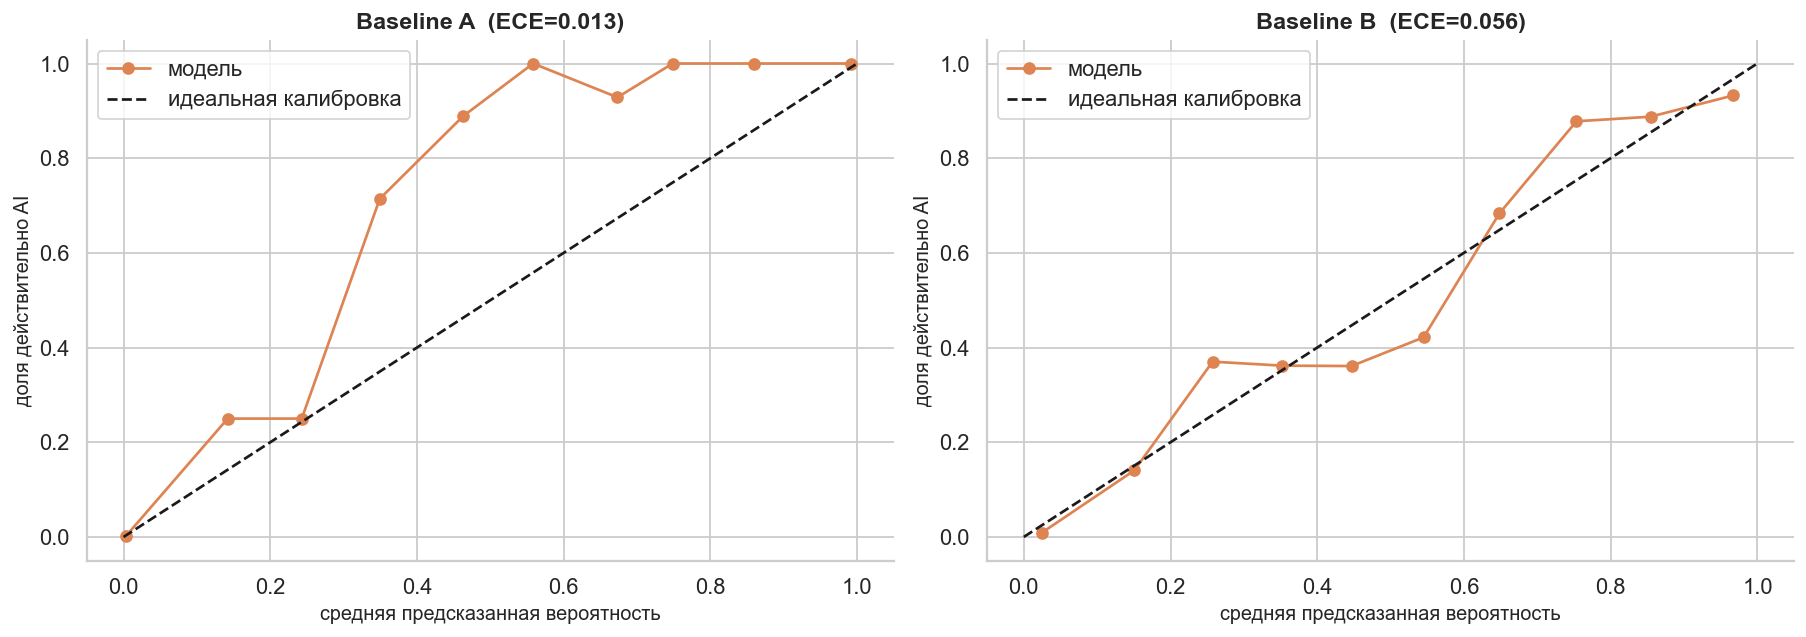

ECE Baseline A: 0.0132
ECE Baseline B: 0.0562


In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (prob, name) in zip(axes, [(prob_A, "Baseline A"), (prob_B, "Baseline B")]):
    frac_pos, mean_pred = calibration_curve(y_test, prob, n_bins=10, strategy="uniform")
    ax.plot(mean_pred, frac_pos, "o-", label="модель", color=C_AI)
    ax.plot([0, 1], [0, 1], "k--", label="идеальная калибровка")
    ax.set_xlabel("средняя предсказанная вероятность")
    ax.set_ylabel("доля действительно AI")
    ece = ece_score(y_test, prob)
    ax.set_title(f"{name}  (ECE={ece:.3f})")
    ax.legend(frameon=True)

plt.tight_layout()
plt.show()

print(f"ECE Baseline A: {ece_score(y_test, prob_A):.4f}")
print(f"ECE Baseline B: {ece_score(y_test, prob_B):.4f}")

A откалиброван хорошо (ECE = 0.013), вероятности можно использовать напрямую. B хуже (ECE = 0.056), завышает уверенность в диапазоне 0.7-0.9. Для deployment B нужна калибровка (Platt scaling).

## Threshold analysis

Нужно найти порог, при котором precision >= 95% - мы не хотим ложно обвинять человеческие тексты.

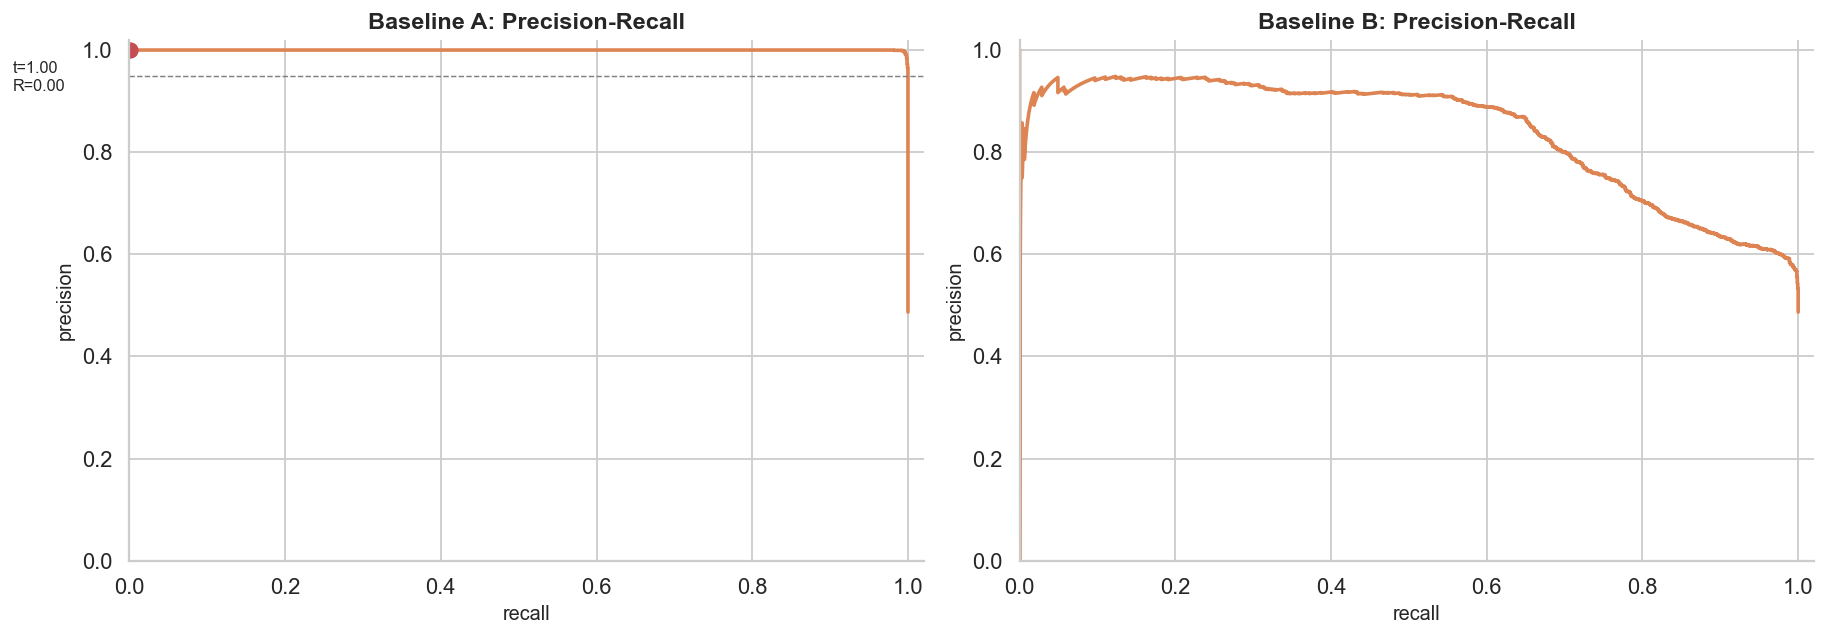

  Baseline A: Precision>=90% -> threshold=1.000, recall=0.001
  Baseline A: Precision>=95% -> threshold=1.000, recall=0.001
  Baseline A: Precision>=99% -> threshold=1.000, recall=0.001
  Baseline B: Precision>=90% -> threshold=0.999, recall=0.015
  Baseline B: Precision>=95% -> недостижимо
  Baseline B: Precision>=99% -> недостижимо


In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (prob, name) in zip(axes, [(prob_A, "Baseline A"), (prob_B, "Baseline B")]):
    prec, rec, thresholds = precision_recall_curve(y_test, prob)
    ax.plot(rec, prec, color=C_AI, lw=2)
    ax.set_xlabel("recall")
    ax.set_ylabel("precision")
    ax.set_title(f"{name}: Precision-Recall")
    ax.set_xlim(0, 1.02)
    ax.set_ylim(0, 1.02)

    # порог precision >= 0.95
    valid = prec[:-1] >= 0.95
    if valid.any():
        idx = np.where(valid)[0][-1]
        ax.axhline(0.95, color="grey", ls="--", lw=0.8)
        ax.plot(rec[idx], prec[idx], "ro", ms=8)
        ax.annotate(f"t={thresholds[idx]:.2f}\nR={rec[idx]:.2f}",
                    xy=(rec[idx], prec[idx]), fontsize=9,
                    xytext=(rec[idx]-0.15, prec[idx]-0.08))

plt.tight_layout()
plt.show()

# note: вынести пороговый анализ в отдельную функцию
for prob, name in [(prob_A, "A"), (prob_B, "B")]:
    prec, rec, thr = precision_recall_curve(y_test, prob)
    for target_prec in [0.90, 0.95, 0.99]:
        valid = prec[:-1] >= target_prec
        if valid.any():
            idx = np.where(valid)[0][-1]
            print(f"  Baseline {name}: Precision>={target_prec:.0%} -> threshold={thr[idx]:.3f}, recall={rec[idx]:.3f}")
        else:
            print(f"  Baseline {name}: Precision>={target_prec:.0%} -> недостижимо")

A при precision >= 95% даёт recall ~0 - кривая вырождается из-за слишком уверенных предсказаний. B не достигает precision 95%.

Оба baseline не обеспечивают приемлемый компромисс precision/recall. Для практического применения с жёстким порогом нужен трансформер или ансамбль.

## Распределение предсказанных вероятностей

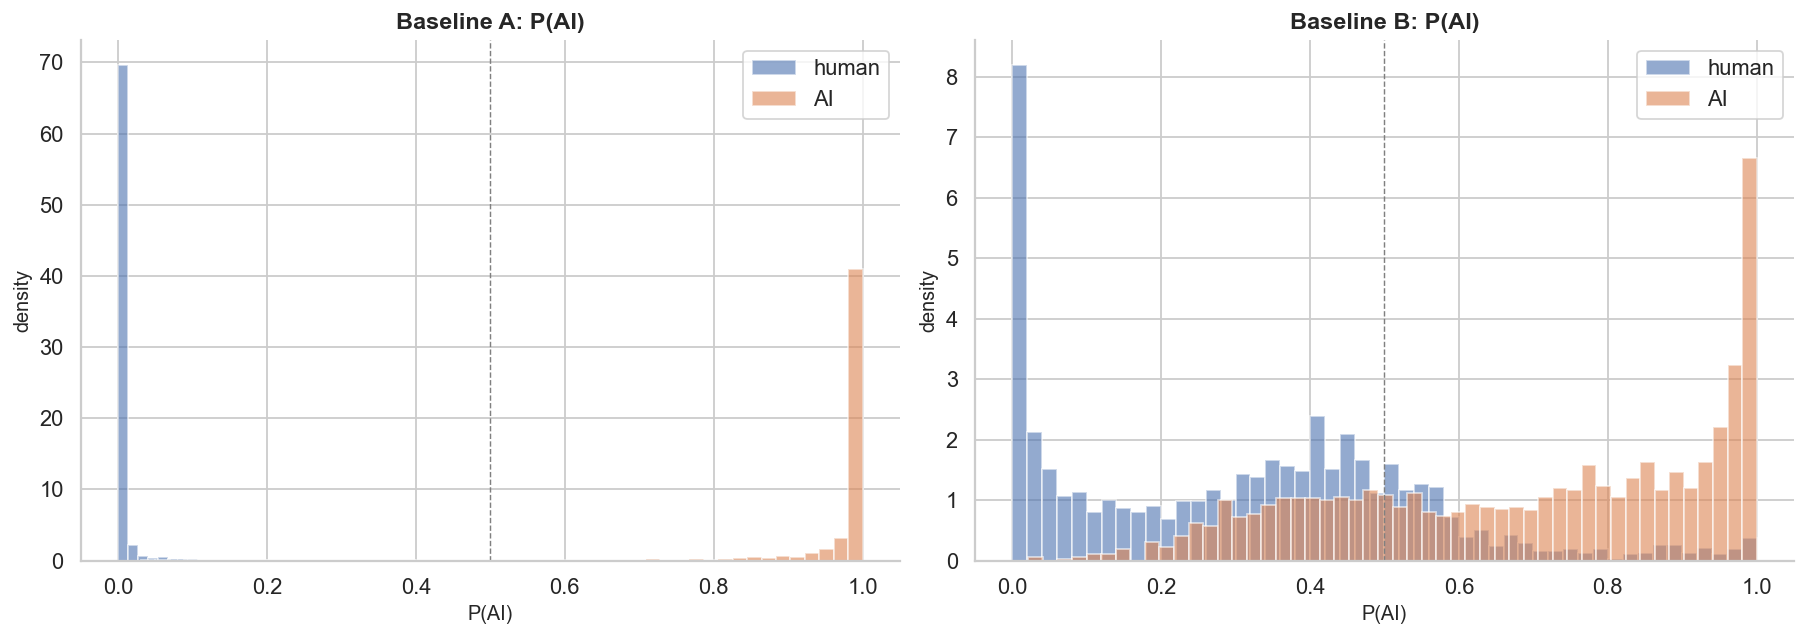

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (prob, name) in zip(axes, [(prob_A, "Baseline A"), (prob_B, "Baseline B")]):
    for label, color, lbl in [(0, C_HUMAN, "human"), (1, C_AI, "AI")]:
        mask = y_test == label
        ax.hist(prob[mask], bins=50, alpha=0.6, color=color, label=lbl, density=True)
    ax.set_xlabel("P(AI)")
    ax.set_ylabel("density")
    ax.set_title(f"{name}: P(AI)")
    ax.legend(frameon=True)
    ax.axvline(0.5, color="grey", ls="--", lw=0.8)

plt.tight_layout()
plt.show()

A - бимодальное распределение (~0.0 и ~1.0), разделение чёткое. Вероятно, модель опирается на тематические маркеры, отсюда высокая уверенность.

B - распределения перекрываются в зоне 0.3-0.7, стилистического сигнала недостаточно для уверенной классификации.

## Сохранение моделей

In [50]:
# note: проверить размер моделей для деплоя
joblib.dump(model_A, ARTIFACTS_DIR / "model_A_logreg.joblib")
joblib.dump(model_B, ARTIFACTS_DIR / "model_B_logreg.joblib")
joblib.dump(tfidf_char, ARTIFACTS_DIR / "tfidf_char.joblib")
joblib.dump(tfidf_word, ARTIFACTS_DIR / "tfidf_word.joblib")
joblib.dump(scaler, ARTIFACTS_DIR / "scaler_B.joblib")

print("Сохранено в artifacts/:")
for p in sorted(ARTIFACTS_DIR.glob("*.joblib")):
    size_mb = p.stat().st_size / 1024 / 1024
    print(f"  {p.name}: {size_mb:.1f} MB")

Сохранено в artifacts/:
  model_A_logreg.joblib: 0.4 MB
  model_B_logreg.joblib: 0.0 MB
  scaler_B.joblib: 0.0 MB
  tfidf_char.joblib: 1.1 MB
  tfidf_word.joblib: 0.9 MB


## Сводная таблица

In [51]:
rows = []
for split_name, y, pA, pB, prA, prB in [
    ("test", y_test, pred_A, pred_B, prob_A, prob_B),
    ("holdout", y_hold, pred_hold_A, pred_hold_B, prob_hold_A, prob_hold_B),
]:
    for mname, pred, prob in [("A (TF-IDF)", pA, prA), ("B (Style)", pB, prB)]:
        rows.append({
            "split": split_name,
            "model": mname,
            "accuracy": accuracy_score(y, pred),
            "F1_macro": f1_score(y, pred, average="macro"),
            "AUC": roc_auc_score(y, prob),
            "ECE": ece_score(y, prob),
            "n": len(y),
        })

# adversarial split
if len(test_adv) > 0:
    rows.append({"split": "adversarial", "model": "A (TF-IDF)",
                 "accuracy": None, "F1_macro": None,
                 "AUC": None, "ECE": None,
                 "n": len(y_adv),
                 "recall_AI": (pred_adv_A == 1).mean()})
    rows.append({"split": "adversarial", "model": "B (Style)",
                 "accuracy": None, "F1_macro": None,
                 "AUC": None, "ECE": None,
                 "n": len(y_adv),
                 "recall_AI": (pred_adv_B == 1).mean()})

pd.DataFrame(rows).round(4)

,split,model,accuracy,F1_macro,AUC,ECE,n,recall_AI
0,test,A (TF-IDF),0.9937,0.9937,0.9999,0.0132,3673,NaN
1,test,B (Style),0.7601,0.7595,0.8518,0.0562,3673,NaN
2,holdout,A (TF-IDF),0.9992,0.9992,1.0000,0.0030,5896,NaN
3,holdout,B (Style),0.8014,0.8014,0.8829,0.0589,5896,NaN
4,adversarial,A (TF-IDF),NaN,NaN,NaN,NaN,511,0.908
5,adversarial,B (Style),NaN,NaN,NaN,NaN,511,0.546


## Выводы

Baseline A (TF-IDF) даёт верхнюю границу качества, но, судя по feature importance, частично опирается на тему. Baseline B (Style-only) показывает нижнюю границу - чистый стилистический сигнал.

На holdout (yandexgpt) видно, насколько модели обобщаются на unseen генератор. Adversarial recall ожидаемо ниже - парафраз маскирует стиль.

note: проверить поведение моделей после topic-matched генерации (DEC-008). Калибровка A приемлема, B требует калибровки для deployment.

---

## Baseline C: TF-IDF на topic-matched данных (DEC-008)

Baseline A показал F1=0.994, но предположительно опирается на тему. Проверяем: обучаем такую же TF-IDF модель на данных, где AI и human пишут об одних темах. Если F1 упадёт - часть сигнала была тематической.

Генераторы в train: GigaChat, Llama 3.3 70B, YandexGPT-Lite. Holdout: Qwen3-32B (unseen).

In [52]:
# загрузка topic-matched splits
train_tm = pd.read_json(DATA_DIR / "train_tm.jsonl", lines=True)
val_tm   = pd.read_json(DATA_DIR / "val_tm.jsonl", lines=True)
test_tm  = pd.read_json(DATA_DIR / "test_tm.jsonl", lines=True)
holdout_tm = pd.read_json(DATA_DIR / "holdout_tm_unseen.jsonl", lines=True)

test_tm_clean = test_tm[test_tm["source_model"] != "adversarial"].copy()
test_tm_adv   = test_tm[test_tm["source_model"] == "adversarial"].copy()

for name, df in [("train_tm", train_tm), ("val_tm", val_tm),
                 ("test_tm_clean", test_tm_clean), ("test_tm_adv", test_tm_adv),
                 ("holdout_tm", holdout_tm)]:
    vc = df["label"].value_counts()
    print(f"{name:15s}: {len(df):>6,}  (human={vc.get(0,0):,}, AI={vc.get(1,0):,})")

train_tm       :  9,000  (human=4,500, AI=4,500)
val_tm         :  1,200  (human=600, AI=600)
test_tm_clean  :  1,800  (human=900, AI=900)
test_tm_adv    :    511  (human=0, AI=511)
holdout_tm     : 12,000  (human=6,000, AI=6,000)


### Обучение TF-IDF на topic-matched

In [53]:
# те же параметры что у Baseline A
tfidf_char_tm = TfidfVectorizer(
    analyzer="char_wb", ngram_range=(3, 5),
    max_features=30_000, sublinear_tf=True,
)
tfidf_word_tm = TfidfVectorizer(
    analyzer="word", ngram_range=(1, 2),
    max_features=20_000, sublinear_tf=True,
    token_pattern=r"(?i)[а-яёa-z]{2,}",
)

X_train_char_tm = tfidf_char_tm.fit_transform(train_tm["text"])
X_train_word_tm = tfidf_word_tm.fit_transform(train_tm["text"])
X_train_C = hstack([X_train_char_tm, X_train_word_tm])
y_train_tm = train_tm["label"].values

X_val_C = hstack([tfidf_char_tm.transform(val_tm["text"]),
                  tfidf_word_tm.transform(val_tm["text"])])
y_val_tm = val_tm["label"].values

print(f"TF-IDF TM: char={X_train_char_tm.shape[1]:,} + word={X_train_word_tm.shape[1]:,}")

TF-IDF TM: char=30,000 + word=20,000


In [54]:
# подбор C на val_tm
best_c_tm, best_f1_tm = 1.0, 0.0
for c in [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 20.0, 50.0]:
    lr = LogisticRegression(C=c, solver="saga", max_iter=1000, random_state=42)
    lr.fit(X_train_C, y_train_tm)
    pred_val = lr.predict(X_val_C)
    prob_val = lr.predict_proba(X_val_C)[:, 1]
    f1_val = f1_score(y_val_tm, pred_val, average="macro")
    auc_val = roc_auc_score(y_val_tm, prob_val)
    print(f"  C={c:<5}  F1={f1_val:.4f}  AUC={auc_val:.4f}")
    if f1_val > best_f1_tm:
        best_f1_tm = f1_val
        best_c_tm = c

print(f"\nЛучший C={best_c_tm} (val F1={best_f1_tm:.4f})")

  C=0.01   F1=0.9733  AUC=0.9959
  C=0.1    F1=0.9900  AUC=0.9988
  C=0.5    F1=0.9925  AUC=0.9996
  C=1.0    F1=0.9942  AUC=0.9998
  C=5.0    F1=0.9967  AUC=1.0000
  C=10.0   F1=0.9967  AUC=1.0000
  C=20.0   F1=0.9967  AUC=1.0000
  C=50.0   F1=0.9975  AUC=1.0000

Лучший C=50.0 (val F1=0.9975)


In [55]:
# модель C на train_tm + val_tm
X_trainval_C = hstack([
    tfidf_char_tm.transform(pd.concat([train_tm, val_tm])["text"]),
    tfidf_word_tm.transform(pd.concat([train_tm, val_tm])["text"]),
])
y_trainval_tm = pd.concat([train_tm, val_tm])["label"].values

model_C = LogisticRegression(C=best_c_tm, solver="saga", max_iter=1000, random_state=42)
model_C.fit(X_trainval_C, y_trainval_tm)
print(f"Baseline C: C={best_c_tm}, обучен на train_tm+val_tm ({len(y_trainval_tm):,})")

Baseline C: C=50.0, обучен на train_tm+val_tm (10,200)


### Evaluation C на test_tm

Реальный уровень TF-IDF без тематического конфаунда.

=== Baseline C (TF-IDF topic-matched) - test_tm (n=1,800) ===
              precision    recall  f1-score   support

       human      0.991     1.000     0.996       900
          AI      1.000     0.991     0.996       900

    accuracy                          0.996      1800
   macro avg      0.996     0.996     0.996      1800
weighted avg      0.996     0.996     0.996      1800

F1-macro: 0.996 [0.992, 0.998] (95% CI)
Accuracy: 0.996 [0.992, 0.998] (95% CI)
AUC-ROC:  1.000 [1.000, 1.000]
ECE:      0.0087



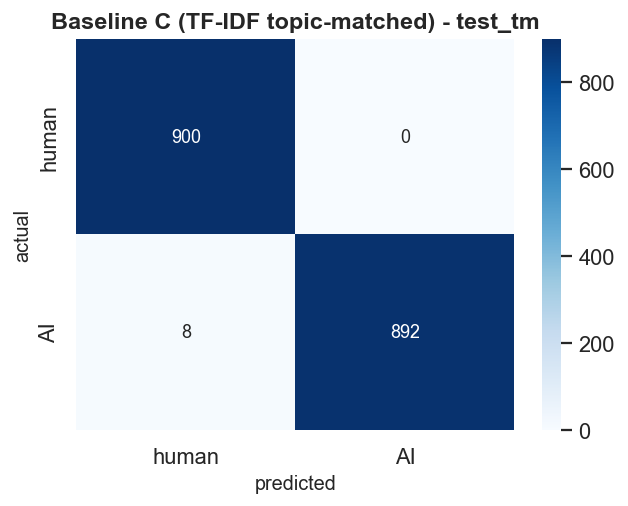

Per-domain:
  essay   : F1=0.998  AUC=1.000  n=600
  news    : F1=0.995  AUC=1.000  n=600
  wiki    : F1=0.993  AUC=1.000  n=600

Per-model (AI only, recall / precision / F1 / avg_prob):
  GigaChat                    : recall=0.984  avg_prob=0.972  n=314
  llama-3.3-70b-versatile     : recall=0.997  avg_prob=0.991  n=313
  yandexgpt-lite              : recall=0.993  avg_prob=0.990  n=273



In [56]:
X_test_C = hstack([tfidf_char_tm.transform(test_tm_clean["text"]),
                   tfidf_word_tm.transform(test_tm_clean["text"])])
y_test_tm = test_tm_clean["label"].values

pred_C, prob_C = evaluate(
    model_C, X_test_C, y_test_tm, "Baseline C (TF-IDF topic-matched) - test_tm",
    domain=test_tm_clean["domain"].values,
    source_model=test_tm_clean["source_model"].values,
)

### Holdout TM - unseen Qwen3-32B

Qwen3 не участвовал в обучении - проверяем обобщение.
ECE на unseen генераторе может быть выше - если так, для deployment нужна калибровка (Platt scaling).

=== Baseline C - holdout_tm (Qwen3 unseen) (n=12,000) ===
              precision    recall  f1-score   support

       human      0.841     0.999     0.913      6000
          AI      0.998     0.811     0.895      6000

    accuracy                          0.905     12000
   macro avg      0.919     0.905     0.904     12000
weighted avg      0.919     0.905     0.904     12000

F1-macro: 0.904 [0.898, 0.909] (95% CI)
Accuracy: 0.904 [0.899, 0.910] (95% CI)
AUC-ROC:  0.995 [0.994, 0.996]
ECE:      0.1069



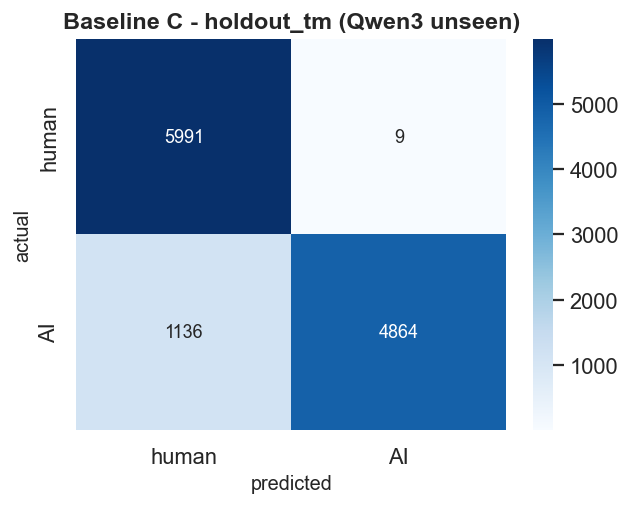

Per-domain:
  essay   : F1=0.797  AUC=0.987  n=3275
  news    : F1=0.925  AUC=0.998  n=5007
  wiki    : F1=0.964  AUC=0.999  n=3718

Per-model (AI only, recall / precision / F1 / avg_prob):
  qwen/qwen3-32b              : recall=0.811  avg_prob=0.778  n=6000



In [57]:
X_hold_C = hstack([tfidf_char_tm.transform(holdout_tm["text"]),
                   tfidf_word_tm.transform(holdout_tm["text"])])
y_hold_tm = holdout_tm["label"].values

pred_hold_C, prob_hold_C = evaluate(
    model_C, X_hold_C, y_hold_tm, "Baseline C - holdout_tm (Qwen3 unseen)",
    domain=holdout_tm["domain"].values,
    source_model=holdout_tm["source_model"].values,
)

### Adversarial на topic-matched

In [58]:
if len(test_tm_adv) > 0:
    X_adv_C = hstack([tfidf_char_tm.transform(test_tm_adv["text"]),
                      tfidf_word_tm.transform(test_tm_adv["text"])])
    prob_adv_C = model_C.predict_proba(X_adv_C)[:, 1]
    pred_adv_C = model_C.predict(X_adv_C)
    recall_adv_C = (pred_adv_C == 1).mean()
    print(f"Adversarial (n={len(test_tm_adv)}): "
          f"recall={recall_adv_C:.3f}  avg_prob={prob_adv_C.mean():.3f}")

Adversarial (n=511): recall=0.755  avg_prob=0.756


## Декомпозиция: A vs C vs B (cross-evaluation)

Для корректного сравнения все модели тестируются на одних данных. Модель A (обученная с конфаундом) применяется к topic-matched test - это покажет, как она справляется без тематических подсказок.

In [59]:
# cross-evaluation: модель A на topic-matched данных
X_test_tm_A = hstack([tfidf_char.transform(test_tm_clean["text"]),
                      tfidf_word.transform(test_tm_clean["text"])])

pred_A_on_tm = model_A.predict(X_test_tm_A)
prob_A_on_tm = model_A.predict_proba(X_test_tm_A)[:, 1]

f1_A_on_tm = f1_score(y_test_tm, pred_A_on_tm, average="macro")
f1_C_on_tm = f1_score(y_test_tm, pred_C, average="macro")
acc_A_on_tm = accuracy_score(y_test_tm, pred_A_on_tm)
acc_C_on_tm = accuracy_score(y_test_tm, pred_C)

# Baseline B на topic-matched test
style_test_tm = extract_style_features(test_tm_clean)
X_test_tm_B = scaler.transform(style_test_tm[STYLE_COLS].values)
pred_B_on_tm = model_B.predict(X_test_tm_B)
prob_B_on_tm = model_B.predict_proba(X_test_tm_B)[:, 1]
f1_B_on_tm = f1_score(y_test_tm, pred_B_on_tm, average="macro")

print("ДЕКОМПОЗИЦИЯ СИГНАЛА (все модели на test_tm)")
print("=" * 60)
print(f"Baseline A (original TF-IDF) на test_tm:  F1={f1_A_on_tm:.3f}  Acc={acc_A_on_tm:.3f}")
print(f"Baseline C (topic-matched TF-IDF) на test_tm: F1={f1_C_on_tm:.3f}  Acc={acc_C_on_tm:.3f}")
print(f"Baseline B (Style-only) на test_tm:       F1={f1_B_on_tm:.3f}")
print()
print(f"A - C на test_tm = {f1_A_on_tm - f1_C_on_tm:+.3f} (A теряет без тематических подсказок)")
print(f"C - B на test_tm = {f1_C_on_tm - f1_B_on_tm:+.3f} (лексический сигнал сверх стиля)")
print(f"A - B на test_tm = {f1_A_on_tm - f1_B_on_tm:+.3f}")
print()
print()
print("Деградация A на topic-matched данных:")
print(f"  A на своём test: F1={f1_A:.3f}")
print(f"  A на test_tm:    F1={f1_A_on_tm:.3f}")
print(f"  Потеря:          {f1_A - f1_A_on_tm:+.3f} (зависимость A от тематического сигнала)")
print()
print("Для справки:")
print(f"  A на test (original):      F1={f1_A:.3f}")
print(f"  C на test_tm:              F1={f1_C_on_tm:.3f}")
print(f"  B на test (original):      F1={f1_B:.3f}")


ДЕКОМПОЗИЦИЯ СИГНАЛА (все модели на test_tm)
Baseline A (original TF-IDF) на test_tm:  F1=0.857  Acc=0.859
Baseline C (topic-matched TF-IDF) на test_tm: F1=0.996  Acc=0.996
Baseline B (Style-only) на test_tm:       F1=0.649

A - C на test_tm = -0.139 (A теряет без тематических подсказок)
C - B на test_tm = +0.346 (лексический сигнал сверх стиля)
A - B на test_tm = +0.207


Деградация A на topic-matched данных:
  A на своём test: F1=0.994
  A на test_tm:    F1=0.857
  Потеря:          +0.137 (зависимость A от тематического сигнала)

Для справки:
  A на test (original):      F1=0.994
  C на test_tm:              F1=0.996
  B на test (original):      F1=0.759


## Обновлённая сводная таблица

Все три baseline на одной таблице.

In [60]:
rows_all = []

# каждая модель на своём test
for mname, f1, acc, auc, n in [
    ("A (TF-IDF)", f1_A, acc_A, roc_auc_score(y_test, prob_A), len(y_test)),
    ("B (Style)", f1_B, acc_B, roc_auc_score(y_test, prob_B), len(y_test)),
]:
    rows_all.append({"eval_set": "test (original)", "model": mname,
                     "F1_macro": f1, "Accuracy": acc, "AUC": auc, "n": n})

rows_all.append({"eval_set": "test_tm", "model": "C (TF-IDF TM)",
                 "F1_macro": f1_C_on_tm, "Accuracy": acc_C_on_tm,
                 "AUC": roc_auc_score(y_test_tm, prob_C), "n": len(y_test_tm)})

# cross-evaluation: все модели на test_tm
rows_all.append({"eval_set": "test_tm (cross)", "model": "A (TF-IDF)",
                 "F1_macro": f1_A_on_tm, "Accuracy": acc_A_on_tm,
                 "AUC": roc_auc_score(y_test_tm, prob_A_on_tm), "n": len(y_test_tm)})
rows_all.append({"eval_set": "test_tm (cross)", "model": "B (Style)",
                 "F1_macro": f1_B_on_tm,
                 "Accuracy": accuracy_score(y_test_tm, pred_B_on_tm),
                 "AUC": roc_auc_score(y_test_tm, prob_B_on_tm), "n": len(y_test_tm)})

# holdout
rows_all.append({"eval_set": "holdout (YandexGPT)", "model": "A (TF-IDF)",
                 "F1_macro": f1_score(y_hold, pred_hold_A, average="macro"),
                 "Accuracy": accuracy_score(y_hold, pred_hold_A),
                 "AUC": roc_auc_score(y_hold, prob_hold_A), "n": len(y_hold)})
rows_all.append({"eval_set": "holdout (Qwen3)", "model": "C (TF-IDF TM)",
                 "F1_macro": f1_score(y_hold_tm, pred_hold_C, average="macro"),
                 "Accuracy": accuracy_score(y_hold_tm, pred_hold_C),
                 "AUC": roc_auc_score(y_hold_tm, prob_hold_C), "n": len(y_hold_tm)})

summary_df = pd.DataFrame(rows_all)
print(summary_df.to_string(index=False, float_format="%.3f"))


           eval_set         model  F1_macro  Accuracy   AUC     n
    test (original)    A (TF-IDF)     0.994     0.994 1.000  3673
    test (original)     B (Style)     0.759     0.760 0.852  3673
            test_tm C (TF-IDF TM)     0.996     0.996 1.000  1800
    test_tm (cross)    A (TF-IDF)     0.857     0.859 0.996  1800
    test_tm (cross)     B (Style)     0.649     0.656 0.735  1800
holdout (YandexGPT)    A (TF-IDF)     0.999     0.999 1.000  5896
    holdout (Qwen3) C (TF-IDF TM)     0.904     0.905 0.995 12000


## Итоговые выводы

Три baseline формируют полную картину сигналов детекции:
- **A** (TF-IDF, original): F1=0.994 на test, но включает тематический конфаунд. Cross-eval на topic-matched данных: F1=0.857, потеря 13.7 п.п.
- **C** (TF-IDF, topic-matched): F1=0.996 на test_tm, F1=0.904 на holdout. Реальный уровень лексического сигнала без конфаунда.
- **B** (Style-only, 10 признаков): F1=0.759. Чистый стилистический сигнал.

Декомпозиция: A-B = +23.5 п.п. (p < 0.001), из них тематический конфаунд ~13.7 п.п. (разница A и A на topic-matched данных), остальное - лексический сигнал сверх стиля.

Per-domain: news наиболее подвержен конфаунду (+39.0 п.п.), wiki наименее (+8.2 п.п.), essay посередине (+16.6 п.п.).

Holdout (unseen generator): C обобщается лучше (F1=0.904), B на holdout F1=0.802 - стилевой сигнал переносится, но слабее.
